In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ieee-fraud-detection/sample_submission.csv
/kaggle/input/ieee-fraud-detection/test_identity.csv
/kaggle/input/ieee-fraud-detection/train_identity.csv
/kaggle/input/ieee-fraud-detection/test_transaction.csv
/kaggle/input/ieee-fraud-detection/train_transaction.csv


In [4]:
!pip install mlflow dagshub --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 52.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 88.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.1/260.1 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 692.3/692.3 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.2/203.2 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This be

In [5]:
import mlflow
from dagshub import dagshub_logger
import os

# Set tracking URI manually
mlflow.set_tracking_uri("https://dagshub.com/ekvirika/FraudDerection.mlflow")

# Use your DagsHub credentials
os.environ["MLFLOW_TRACKING_USERNAME"] = "ekvirika"
os.environ["MLFLOW_TRACKING_PASSWORD"] = "3f601f2c2c7a6bca448ebc69f4f5d4b49daffd8f"

# Optional: set registry if you're using model registry
mlflow.set_registry_uri("https://dagshub.com/ekvirika/FraudDerection.mlflow")

# Cleaning and Preprocessing

Train shape after merge: (590540, 434)


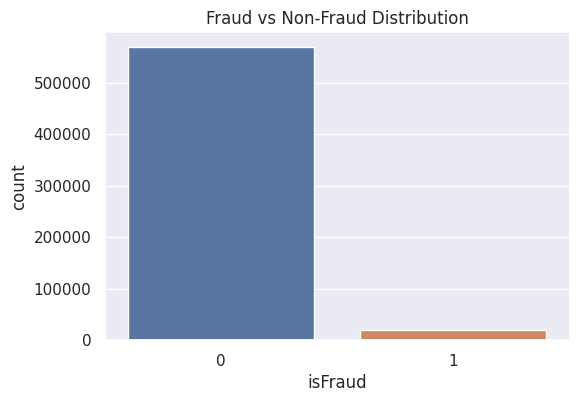

Fraud ratio: 3.50%


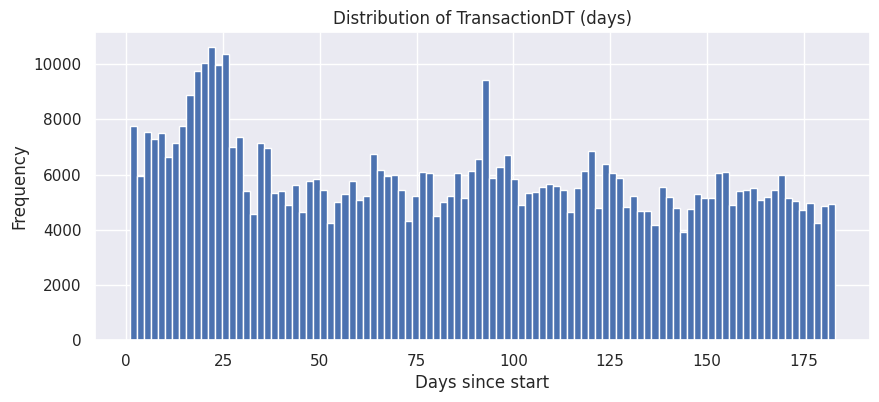

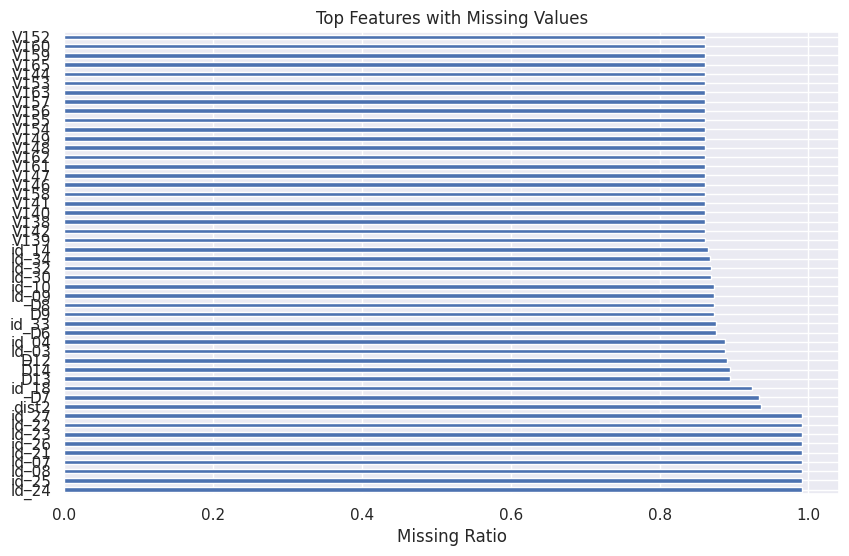

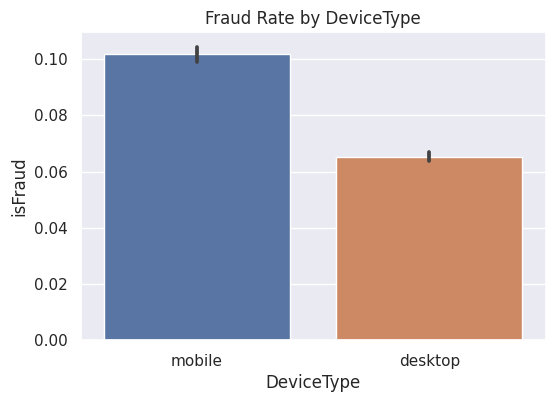

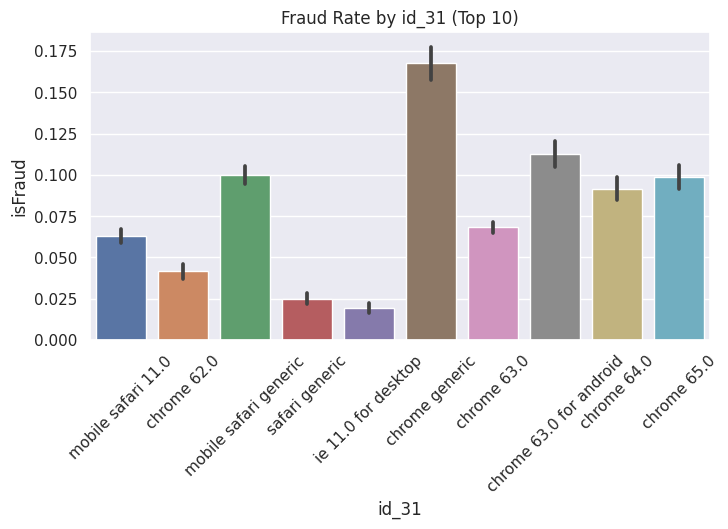

In [8]:
# 01_data_preprocessing_and_eda

# === Imports ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set(style='darkgrid')

# === Load Data ===
train_transaction = pd.read_csv('/kaggle/input/ieee-fraud-detection/train_transaction.csv')
train_identity = pd.read_csv('/kaggle/input/ieee-fraud-detection/train_identity.csv')

# Merge on TransactionID
train = train_transaction.merge(train_identity, on='TransactionID', how='left')
print("Train shape after merge:", train.shape)

# === Target Distribution ===
plt.figure(figsize=(6, 4))
sns.countplot(x='isFraud', data=train)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

print("Fraud ratio: {:.2f}%".format(train['isFraud'].mean() * 100))

# === TransactionDT Analysis ===
# Convert to timedelta days (roughly)
train['TransactionDT_days'] = train['TransactionDT'] / (3600 * 24)

plt.figure(figsize=(10, 4))
train['TransactionDT_days'].plot.hist(bins=100)
plt.title("Distribution of TransactionDT (days)")
plt.xlabel("Days since start")
plt.show()

# === Missing Values ===
missing = train.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]

plt.figure(figsize=(10, 6))
missing.head(50).plot.barh()
plt.title("Top Features with Missing Values")
plt.xlabel("Missing Ratio")
plt.show()

# Save missing info
missing.to_csv('missing_value_ratios.csv')

# === DeviceType and id_31 effect ===
plt.figure(figsize=(6, 4))
sns.barplot(x='DeviceType', y='isFraud', data=train)
plt.title("Fraud Rate by DeviceType")
plt.show()

plt.figure(figsize=(8, 4))
top_id_31 = train['id_31'].value_counts().index[:10]
sns.barplot(x='id_31', y='isFraud', data=train[train['id_31'].isin(top_id_31)])
plt.xticks(rotation=45)
plt.title("Fraud Rate by id_31 (Top 10)")
plt.show()


# Feature Engineeering

In [9]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import LabelEncoder
import logging
import hashlib

logging.basicConfig(level=logging.INFO, format='[%(levelname)s] %(message)s')

class FeatureEngineeringTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.label_encoders = {}
        self.nan_fill_value = -999
        self.outlier_fill_value = -9999
        self.uid_cols = ['card1', 'card2', 'addr1']
        self.label_cols = []

    def fit(self, X, y=None):
        logging.info("Fitting FeatureEngineeringTransformer...")
        X = X.copy()

        # Label encode object (categorical) columns
        self.label_cols = X.select_dtypes(include='object').columns.tolist()
        for col in self.label_cols:
            X[col] = X[col].fillna('NA')
            le = LabelEncoder()
            try:
                le.fit(X[col])
                self.label_encoders[col] = le
            except Exception as e:
                logging.warning(f"LabelEncoder failed for {col}: {e}")

        logging.info(f"Fitted {len(self.label_cols)} categorical columns.")
        return self

    def transform(self, X):
        logging.info("Transforming dataset...")
        X = X.copy()
        X.fillna(self.nan_fill_value, inplace=True)

        # Label encode
        for col in self.label_cols:
            le = self.label_encoders.get(col)
            if le:
                try:
                    X[col] = le.transform(X[col].fillna('NA'))
                except Exception:
                    logging.warning(f"New unseen label in {col}, setting as 0")
                    X[col] = 0

        # Hash-based UID encoding
        uid_series = X[self.uid_cols[0]].astype(str)
        for col in self.uid_cols[1:]:
            uid_series += '_' + X[col].astype(str)

        def hash_uid(uid_str):
            return int(hashlib.md5(uid_str.encode()).hexdigest()[:8], 16)

        X['uid'] = uid_series.apply(hash_uid)

        # TransactionDT features
        X['TransactionDT_days'] = X['TransactionDT'] / (3600 * 24)
        X['Transaction_hour'] = (X['TransactionDT'] // 3600) % 24
        X['Transaction_day'] = (X['TransactionDT'] // (3600 * 24)) % 7

        # Cents from TransactionAmt
        X['TransactionAmt_cents'] = ((X['TransactionAmt'] - X['TransactionAmt'].astype(int)) * 100).astype(int)

        # Replace rare values
        for col in ['ProductCD', 'card4', 'card6']:
            if col in X.columns:
                freq = X[col].value_counts()
                rare_values = freq[freq < 100].index
                X[col] = X[col].replace(rare_values, self.outlier_fill_value)

        logging.info(f"Transformed shape: {X.shape}")
        return X


# Training

In [10]:
# === Imports ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import logging
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, confusion_matrix
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
import lightgbm as lgb
import joblib
import os
import json
from datetime import datetime

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# === Load Data ===
X = train.drop(columns=['isFraud'])
y = train['isFraud']

# === Train/Validation Split ===
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Print class distribution
logging.info(f"Training set class distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}")
logging.info(f"Validation set class distribution: {dict(zip(*np.unique(y_val, return_counts=True)))}")

[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.283925 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 39263
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 407
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
🏃 View run lightgbm-run-20250430_011543 at: https://dagshub.com/ekvirika/FraudDerection.mlflow/#/experiments/9/runs/8fe22d94a2ef4685b7d2f162d765f886
🧪 View experiment at: https://dagshub.com/ekvirika/FraudDerection.mlflow/#/experiments/9


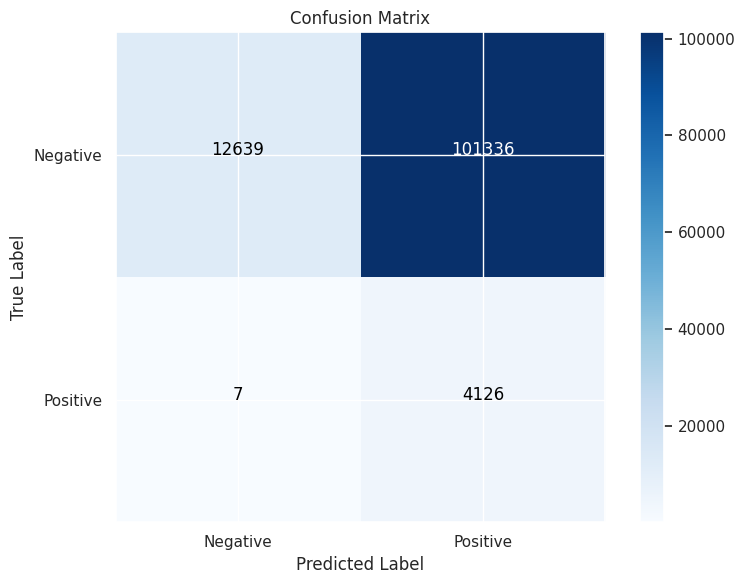

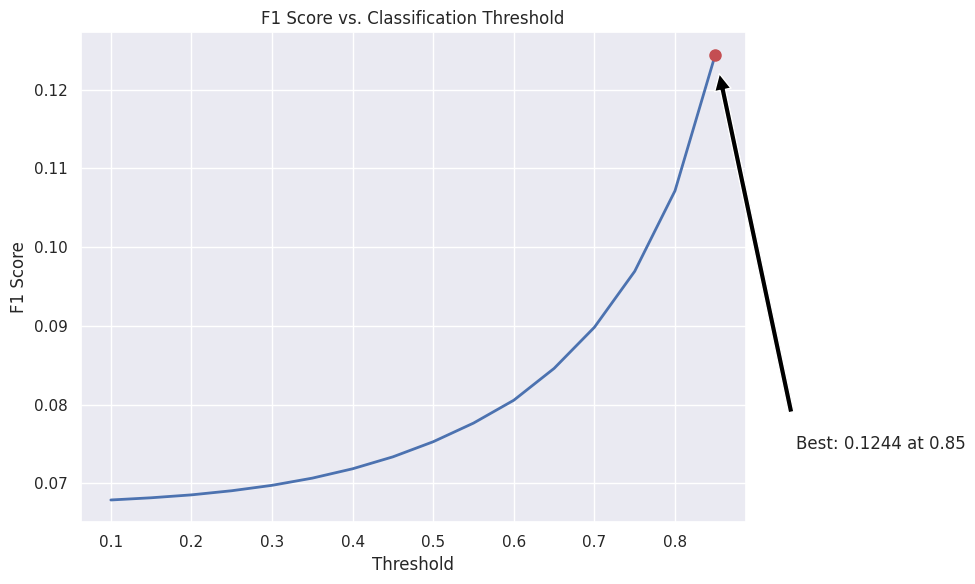

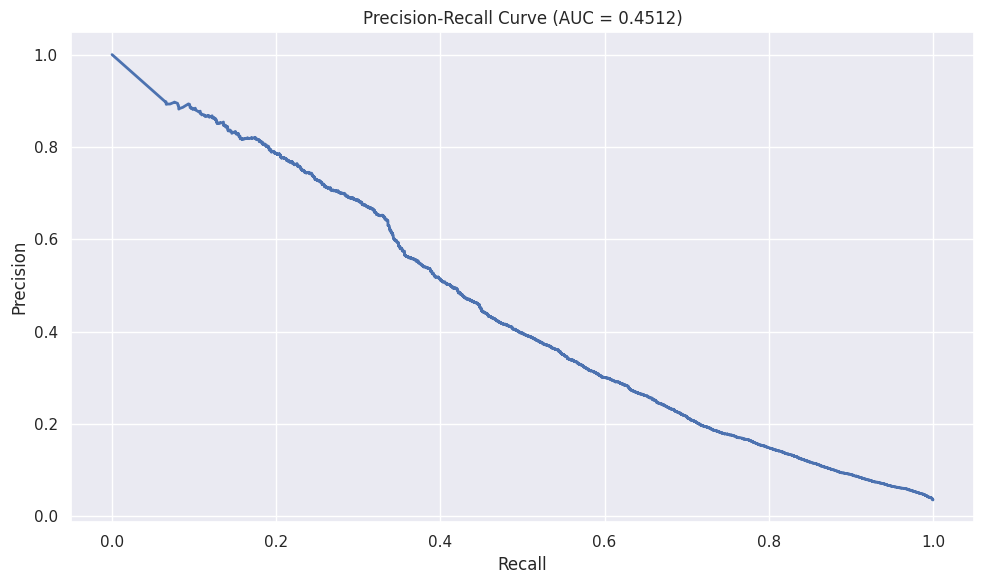

In [11]:
# === MLflow Setup ===
experiment_name = "LightGBM_Training"
mlflow.set_experiment(experiment_name)

# Create a unique run name with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_name = f"lightgbm-run-{timestamp}"

with mlflow.start_run(run_name=run_name) as run:
    run_id = run.info.run_id
    logging.info(f"MLflow Run ID: {run_id}")
    
    # === Define Model ===
    lgb_model = lgb.LGBMClassifier(
        n_estimators=100,
        learning_rate=0.05,
        num_leaves=25,
        max_depth=10,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        class_weight='balanced',
        scale_pos_weight=25,  # Adjust based on class imbalance
        objective='binary',
        metric='auc'
    )

    # === Log Data Information ===
    mlflow.log_param("training_samples", len(X_train))
    mlflow.log_param("validation_samples", len(X_val))
    mlflow.log_param("positive_class_ratio_train", np.mean(y_train))
    mlflow.log_param("positive_class_ratio_val", np.mean(y_val))
    mlflow.log_param("features_count", X_train.shape[1])

    # === Pipeline ===
    pipeline = Pipeline([
        ('features', FeatureEngineeringTransformer()),
        ('model', lgb_model)
    ])

    # Log model hyperparameters
    for param_name, param_value in lgb_model.get_params().items():
        mlflow.log_param(f"model_{param_name}", param_value)

    # Track start time
    start_time = datetime.now()
    
    # Fit the model
    pipeline.fit(X_train, y_train)
    
    # Track training duration
    training_duration = (datetime.now() - start_time).total_seconds()
    mlflow.log_metric("training_duration_seconds", training_duration)
    
    # Predict with the model
    y_pred_proba = pipeline.predict_proba(X_val)[:, 1]
    y_pred = (y_pred_proba >= 0.5).astype(int)
    
    # === Calculate and Log Metrics ===
    metrics = {}
    metrics["val_accuracy"] = accuracy_score(y_val, y_pred)
    metrics["val_precision"] = precision_score(y_val, y_pred)
    metrics["val_recall"] = recall_score(y_val, y_pred)
    metrics["val_f1"] = f1_score(y_val, y_pred)
    metrics["val_auc"] = roc_auc_score(y_val, y_pred_proba)
    
    # Log confusion matrix as a figure
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(2)
    plt.xticks(tick_marks, ['Negative', 'Positive'])
    plt.yticks(tick_marks, ['Negative', 'Positive'])
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    
    # Add text annotations to confusion matrix
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                    horizontalalignment="center",
                    color="white" if cm[i, j] > thresh else "black")
    
    # Save and log the confusion matrix figure
    cm_path = "confusion_matrix.png"
    plt.tight_layout()
    plt.savefig(cm_path)
    mlflow.log_artifact(cm_path)
    
    # Find optimal threshold for F1 score
    thresholds = np.arange(0.1, 0.9, 0.05)
    f1_scores = [f1_score(y_val, y_pred_proba > t) for t in thresholds]
    best_thresh_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_thresh_idx]
    best_f1 = f1_scores[best_thresh_idx]
    
    logging.info(f"Best threshold for F1: {best_thresh}")
    mlflow.log_metric("best_threshold", best_thresh)
    mlflow.log_metric("best_threshold_f1", best_f1)
    
    # Log and visualize the threshold vs F1 curve
    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, f1_scores, 'b-', linewidth=2)
    plt.plot(best_thresh, best_f1, 'ro', markersize=8)
    plt.xlabel('Threshold')
    plt.ylabel('F1 Score')
    plt.title('F1 Score vs. Classification Threshold')
    plt.grid(True)
    plt.annotate(f'Best: {best_f1:.4f} at {best_thresh:.2f}', 
                 xy=(best_thresh, best_f1),
                 xytext=(best_thresh+0.1, best_f1-0.05),
                 arrowprops=dict(facecolor='black', shrink=0.05))
    
    # Save and log the threshold curve
    threshold_path = "threshold_curve.png"
    plt.tight_layout()
    plt.savefig(threshold_path)
    mlflow.log_artifact(threshold_path)
    
    # Plot precision-recall curve
    precision, recall, pr_thresholds = precision_recall_curve(y_val, y_pred_proba)
    pr_auc = auc(recall, precision)
    metrics["pr_auc"] = pr_auc
    
    plt.figure(figsize=(10, 6))
    plt.plot(recall, precision, 'b-', linewidth=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve (AUC = {pr_auc:.4f})')
    plt.grid(True)
    
    # Save and log the PR curve
    pr_curve_path = "pr_curve.png"
    plt.tight_layout()
    plt.savefig(pr_curve_path)
    mlflow.log_artifact(pr_curve_path)

    

2025/04/30 01:17:20 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'LightGBM_Fraud_Detection' already exists. Creating a new version of this model...
2025/04/30 01:17:23 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: LightGBM_Fraud_Detection, version 2
Created version '2' of model 'LightGBM_Fraud_Detection'.


Training and evaluation completed. Model logged to MLflow with run ID: 8fe22d94a2ef4685b7d2f162d765f886


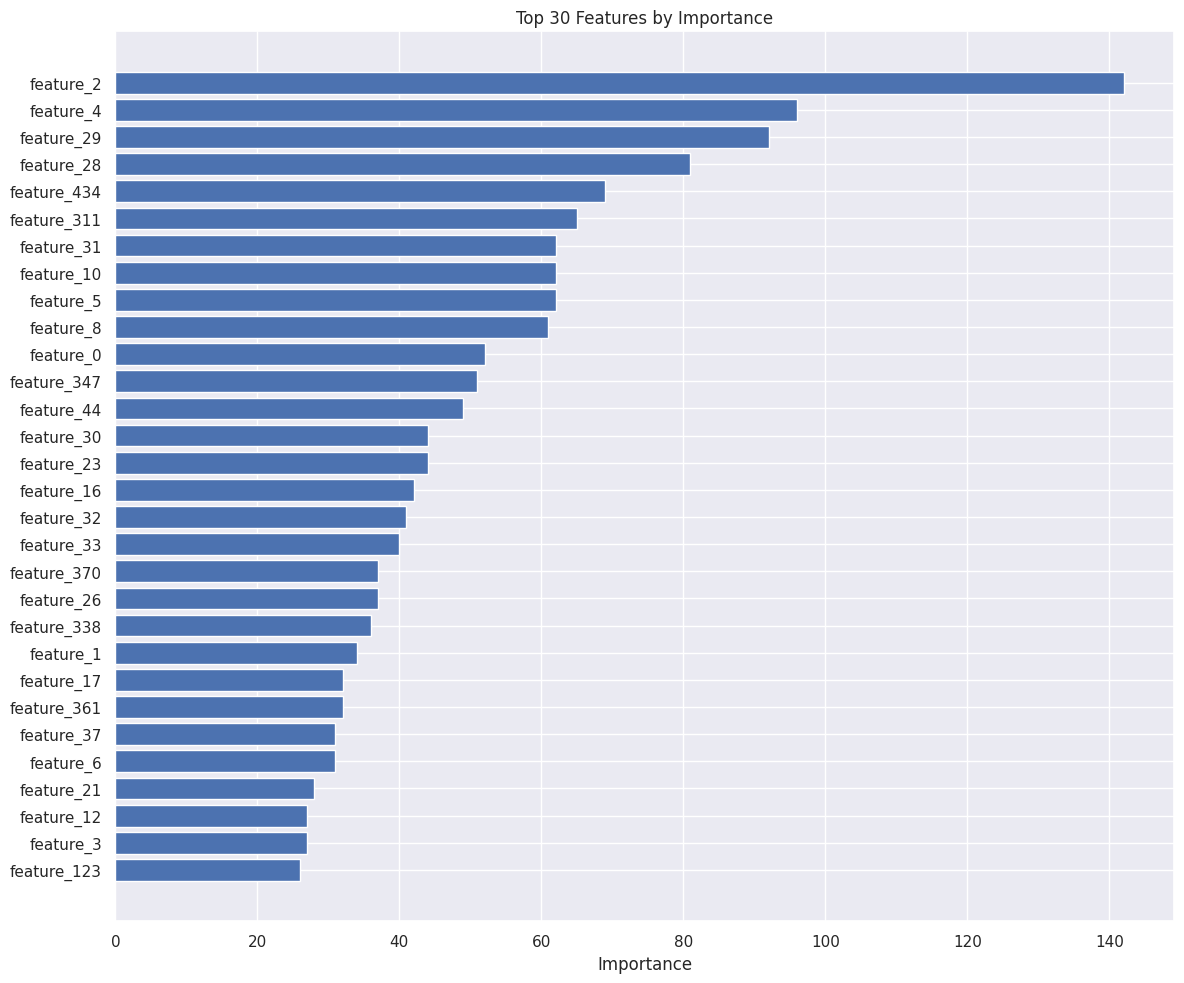

In [12]:
    # Log all metrics
    for metric_name, metric_value in metrics.items():
        mlflow.log_metric(metric_name, metric_value)
        logging.info(f"{metric_name}: {metric_value:.4f}")
    
    # Feature importance visualization - Fixed approach
    if hasattr(pipeline.named_steps['model'], 'feature_importances_'):
        # Get feature importances from the model
        importances = pipeline.named_steps['model'].feature_importances_
        
        # If your FeatureEngineeringTransformer doesn't have get_feature_names_out,
        # you need to implement a way to get feature names
        try:
            # Try to get feature names if method exists
            feature_names = pipeline.named_steps['features'].get_feature_names_out()
        except AttributeError:
            # Fallback: Create generic feature names based on original features
            # You should implement a get_feature_names method in your transformer
            # or adapt this based on your transformer's behavior
            if hasattr(pipeline.named_steps['features'], 'get_feature_names'):
                feature_names = pipeline.named_steps['features'].get_feature_names()
            else:
                # Create generic feature names
                feature_names = [f"feature_{i}" for i in range(len(importances))]
        
        # Create and log feature importance data
        feature_importance_data = list(zip(feature_names, importances))
        feature_importance_df = pd.DataFrame(feature_importance_data, 
                                         columns=['Feature', 'Importance'])
        feature_importance_df = feature_importance_df.sort_values(
            by='Importance', ascending=False)
        
        # Log top feature importances as parameters
        for i, (feature, importance) in enumerate(
            feature_importance_df.head(10).values):
            mlflow.log_param(f"top_feature_{i+1}", f"{feature} ({importance:.4f})")
        
        # Save feature importance to CSV
        feature_importance_path = "feature_importance.csv"
        feature_importance_df.to_csv(feature_importance_path, index=False)
        mlflow.log_artifact(feature_importance_path)
        
        # Plot top 30 features (or all if less than 30)
        plt.figure(figsize=(12, 10))
        top_n = min(30, len(feature_importance_df))
        top_features = feature_importance_df.head(top_n)
        plt.barh(top_features['Feature'], top_features['Importance'])
        plt.gca().invert_yaxis()
        plt.xlabel('Importance')
        plt.title(f"Top {top_n} Features by Importance")
        plt.tight_layout()
        
        # Save and log the feature importance plot
        feature_plot_path = "feature_importance.png"
        plt.savefig(feature_plot_path)
        mlflow.log_artifact(feature_plot_path)
    
    # === Log the Model ===
    mlflow.sklearn.log_model(
        pipeline, 
        "model",
        registered_model_name="LightGBM_Fraud_Detection"
    )
    
    # Save model artifacts locally as well
    model_dir = "model_artifacts"
    os.makedirs(model_dir, exist_ok=True)
    joblib.dump(pipeline, f"{model_dir}/best_model.pkl")
    
    # Log model metadata
    model_metadata = {
        "framework": "LightGBM",
        "pipeline_steps": list(pipeline.named_steps.keys()),
        "feature_count": X_train.shape[1],  # Original feature count
        "training_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "mlflow_run_id": run_id,
        "description": "Fraud detection model using LightGBM"
    }
    
    with open(f"{model_dir}/model_metadata.json", "w") as f:
        json.dump(model_metadata, f, indent=2)
    
    mlflow.log_artifact(f"{model_dir}/model_metadata.json")
    
    logging.info(f"Model successfully logged to MLflow with run ID: {run_id}")
    logging.info(f"Model registered as 'LightGBM_Fraud_Detection'")
    print(f"Training and evaluation completed. Model logged to MLflow with run ID: {run_id}")

# Resampling experiment

In [ ]:
# === Load Data ===
X = train.drop(columns=['isFraud'])
y = train['isFraud']

# === Train/Validation Split ===
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)


In [13]:
!pip install imbalanced-learn==0.11.0 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.6/235.6 kB 6.2 MB/s eta 0:00:00:00:01


In [ ]:
import mlflow
import mlflow.sklearn
import logging
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from lightgbm import LGBMClassifier

# --- Define balancing strategies ---
resampling_methods = {
    "no_resampling": None,
    "scale_pos_weight": "scale_pos_weight",
    "class_weight_balanced": "class_weight",
    "random_oversampler": RandomOverSampler(random_state=42),
    "smote": SMOTE(random_state=42),
    "random_undersampler": RandomUnderSampler(random_state=42)
}

from sklearn.feature_selection import SelectKBest, mutual_info_classif

def run_experiment(X_train, X_val, y_train, y_val):
    for name, method in resampling_methods.items():
        with mlflow.start_run(run_name=f"lgbm_{name}"):
            logging.info(f"Running resampling strategy: {name}")
            
            # Feature selector
            feature_selector = SelectKBest(score_func=mutual_info_classif, k=50)

            if method is None:
                model = LGBMClassifier(random_state=42)
                steps = [
                    ("feature_engineering", FeatureEngineeringTransformer()),
                    ("feature_selection", feature_selector),
                    ("model", model)
                ]
            elif method == "scale_pos_weight":
                model = LGBMClassifier(scale_pos_weight=27.6, random_state=42)
                steps = [
                    ("feature_engineering", FeatureEngineeringTransformer()),
                    ("feature_selection", feature_selector),
                    ("model", model)
                ]
            elif method == "class_weight":
                model = LGBMClassifier(class_weight="balanced", random_state=42)
                steps = [
                    ("feature_engineering", FeatureEngineeringTransformer()),
                    ("feature_selection", feature_selector),
                    ("model", model)
                ]
            else:
                model = LGBMClassifier(random_state=42)
                steps = [
                    ("feature_engineering", FeatureEngineeringTransformer()),
                    ("resample", method),
                    ("feature_selection", feature_selector),
                    ("model", model)
                ]

            pipeline = ImbPipeline(steps)
            pipeline.fit(X_train, y_train)
            y_pred = pipeline.predict(X_val)
            y_pred_proba = pipeline.predict_proba(X_val)[:, 1]

            f1 = f1_score(y_val, y_pred)
            auc = roc_auc_score(y_val, y_pred_proba)

            mlflow.log_param("resampling", name)
            mlflow.log_param("feature_selection", "SelectKBest(mutual_info)")
            mlflow.log_metric("f1_score", f1)
            mlflow.log_metric("roc_auc", auc)

            logging.info(f"{name} - F1: {f1:.4f}, ROC AUC: {auc:.4f}")

In [ ]:
run_experiment(X_train, X_val, y_train, y_val)


In [ ]:
train_transaction = pd.read_csv('/kaggle/input/ieee-fraud-detection/train_transaction.csv')
train_identity = pd.read_csv('/kaggle/input/ieee-fraud-detection/train_identity.csv')